In [112]:
import requests # popular Python library for making HTTP requests (GET, POST, PUT, DELETE, etc.).
import json
import codecs
# We send a GET request to the API endpoint to retrieve product data in JSON format:
API_URL = "https://raw.githubusercontent.com/cp099/India-Air-Quality-Dataset/refs/heads/main/Delhi_AQI_Dataset.csv"
resp = requests.get(API_URL) # simple GET, no auth
##with open(resp, 'r') as j:
     ##contents = json.loads(j.read())

##response_json = resp.decode('utf-8')
#resp.encoding='utf-8-sig'
#resp=resp.content.decode('utf-8-sig')
#resp = json.loads(resp)
#decoded_data=codecs.decode(resp.text.encode(), 'utf-8-sig')
#data = json.loads(decoded_data)
#products_json = resp.json()    # list of product
#print(len(resp), resp[0])  # quick peek (count + first item)


In [31]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

In [113]:
import csv
import io
import json
import pandas as pd


# Your API string response
decoded_data=codecs.decode(resp.text.encode(), 'utf-8')
csv_data_string = decoded_data

# 1. Wrap the string in StringIO to treat it like a file
f = io.StringIO(csv_data_string.strip())

# 2. Read the CSV using DictReader (uses the first row as keys)
reader = csv.DictReader(f)

# 3. Convert rows into a list of dictionaries
data_list = list(reader)

# 4. Convert the list of dicts to a formatted JSON string
json_data = json.dumps(data_list, indent=4)
json_data = json.loads(json_data)
data = pd.DataFrame(json_data)
print(data.head())


   ﻿City      Date  AQI  PM2.5    PM10     NO2     SO2    CO     O3  
0  Delhi  01/01/18  406  223.3  438.48  336.98  462.84  4.26  385.7  
1  Delhi  02/01/18  418  229.9  451.44  346.94  476.52  4.39  397.1  
2  Delhi  03/01/18  382  210.1  412.56  317.06  435.48  4.01  362.9  
3  Delhi  04/01/18  366  201.3  395.28  303.78  417.24  3.84  347.7  
4  Delhi  05/01/18  390  214.5   421.2   323.7   444.6   4.1  370.5  


In [114]:
###basic checking of data
display(data.shape)
data.info()
data.isna().sum()

##No nulls which is ideal, however dates and floats are sting data

(2191, 10)

<class 'pandas.DataFrame'>
RangeIndex: 2191 entries, 0 to 2190
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   ﻿City   2191 non-null   str  
 1   Date    2191 non-null   str  
 2   AQI     2191 non-null   str  
 3   PM2.5   2191 non-null   str  
 4   PM10    2191 non-null   str  
 5   NO2     2191 non-null   str  
 6   SO2     2191 non-null   str  
 7   CO      2191 non-null   str  
 8   O3      2191 non-null   str  
 9           2191 non-null   str  
dtypes: str(10)
memory usage: 171.3 KB


City    0
Date     0
AQI      0
PM2.5    0
PM10     0
NO2      0
SO2      0
CO       0
O3       0
         0
dtype: int64

In [115]:
##remove last column

data = data.drop(columns=data.columns[9])

In [116]:
data["Date"] = pd.to_datetime(data["Date"], format="%d/%m/%y")

In [49]:
(pd.DatetimeIndex(data["Date"]).year).unique()

Index([2018, 2019, 2020, 2021, 2023, 2024], dtype='int32', name='Date')

In [40]:
data.set_index("Date", inplace=True)

In [50]:
data.head()

,﻿City,Date,AQI,PM2.5,PM10,NO2,SO2,CO,O3
0,Delhi,2018-01-01,406,223.3,438.48,336.98,462.84,4.26,385.7
1,Delhi,2018-01-02,418,229.9,451.44,346.94,476.52,4.39,397.1
2,Delhi,2018-01-03,382,210.1,412.56,317.06,435.48,4.01,362.9
3,Delhi,2018-01-04,366,201.3,395.28,303.78,417.24,3.84,347.7
4,Delhi,2018-01-05,390,214.5,421.2,323.7,444.6,4.1,370.5


In [117]:
data["AQI"] = data["AQI"].astype(int)
data["PM2.5"] = data["PM2.5"].astype(float)
data["PM10"] = data["PM10"].astype(float)
data["NO2"] = data["NO2"].astype(float)
data["SO2"] = data["SO2"].astype(float)
data["CO"] = data["CO"].astype(float)
data["O3"] = data["O3"].astype(float)

In [4]:
import pandas as pd
data = pd.read_csv("data/processed/delhi_processed_data.csv")

In [ ]:
#data.info()
data["Date"] = pd.to_datetime(data["Date"], format="%Y-%m-%d")

In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2191 entries, 0 to 2190
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   City    2191 non-null   str           
 1   Date    2191 non-null   datetime64[us]
 2   AQI     2191 non-null   int64         
 3   PM2.5   2191 non-null   float64       
 4   PM10    2191 non-null   float64       
 5   NO2     2191 non-null   float64       
 6   SO2     2191 non-null   float64       
 7   CO      2191 non-null   float64       
 8   O3      2191 non-null   float64       
dtypes: datetime64[us](1), float64(6), int64(1), str(1)
memory usage: 164.9 KB


In [10]:
data["Week"] = data["Date"].dt.isocalendar()["week"]
data["Year"] = data["Date"].dt.isocalendar()["year"]

data["Week"] = data["Week"].astype(str)
data["Year"] = data["Year"].astype(str)
data["Sunday"] = data["Date"] + pd.offsets.Week(n=1, weekday=6)

In [11]:
##Now data is numerical, describe 
data.describe()

,Date,AQI,PM2.5,PM10,NO2,SO2,CO,O3,Sunday
count,2191,2191.000000,2191.000000,2191.000000,2191.000000,2191.000000,2191.000000,2191.000000,2191
mean,2021-05-02 10:01:22.154267,208.285714,114.557143,224.948571,172.877143,237.445714,2.187307,197.871429,2021-05-06 10:07:17.060703
min,2018-01-01 00:00:00,41.000000,22.550000,44.280000,34.030000,46.740000,0.430000,38.950000,2018-01-07 00:00:00
25%,2019-07-02 12:00:00,117.000000,64.350000,126.360000,97.110000,133.380000,1.230000,111.150000,2019-07-07 00:00:00
50%,2021-01-01 00:00:00,190.000000,104.500000,205.200000,157.700000,216.600000,2.000000,180.500000,2021-01-03 00:00:00
75%,2023-07-02 12:00:00,289.000000,158.950000,312.120000,239.870000,329.460000,3.030000,274.550000,2023-07-09 00:00:00
max,2024-12-31 00:00:00,494.000000,271.700000,533.520000,410.020000,563.160000,5.190000,469.300000,2025-01-05 00:00:00
std,NaN,106.614654,58.638060,115.143827,88.490163,121.540706,1.119494,101.283922,NaN


In [ ]:
##group data by week, might make the predictions better as the seasonality will match the granularity, avg, doesn't make sense to sum 
##why are we grouping? 
data_weekly = data.groupby(["Sunday"]).agg(
    AQI = ("AQI", "mean"),	
    PM25 = ("PM2.5", "mean"),	
    PM10 = ("PM10", "mean"),	
    NO2 = ("NO2","mean"),
    SO2 = ("SO2", "mean"),	
    CO = ("CO","mean"),	
    O3 = ("O3","mean")
 )
data_weekly = data_weekly.reset_index()
#data_weekly["Year-week"] = data_weekly["Year"] + "-" + data_weekly["Week"]


data_weekly.info()


<class 'pandas.DataFrame'>
RangeIndex: 314 entries, 0 to 313
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Sunday  314 non-null    datetime64[us]
 1   AQI     314 non-null    float64       
 2   PM25    314 non-null    float64       
 3   PM10    314 non-null    float64       
 4   NO2     314 non-null    float64       
 5   SO2     314 non-null    float64       
 6   CO      314 non-null    float64       
 7   O3      314 non-null    float64       
dtypes: datetime64[us](1), float64(7)
memory usage: 19.8 KB


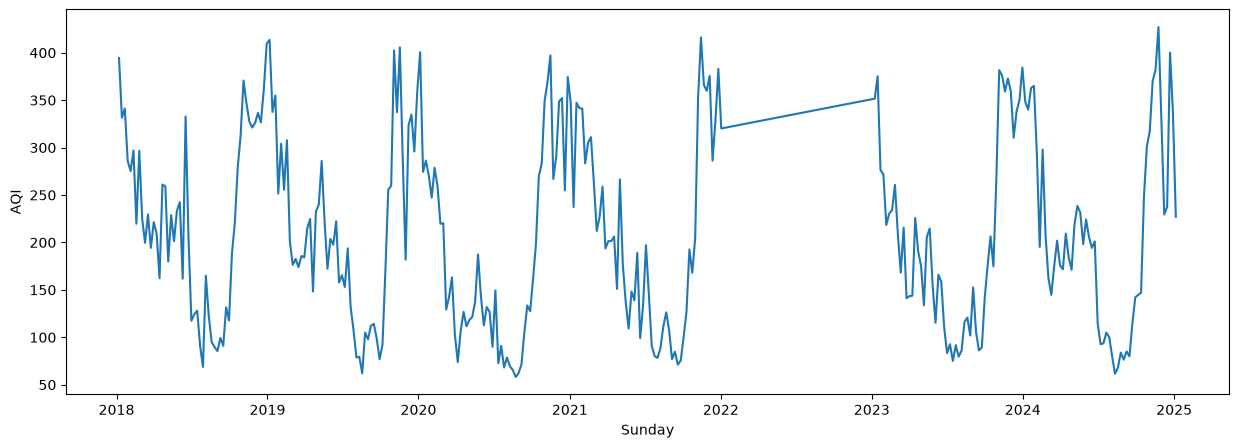

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))
sns.lineplot(x="Sunday", y= "AQI", data = data_weekly)
plt.show()

<Axes: xlabel='Count', ylabel='Sunday'>

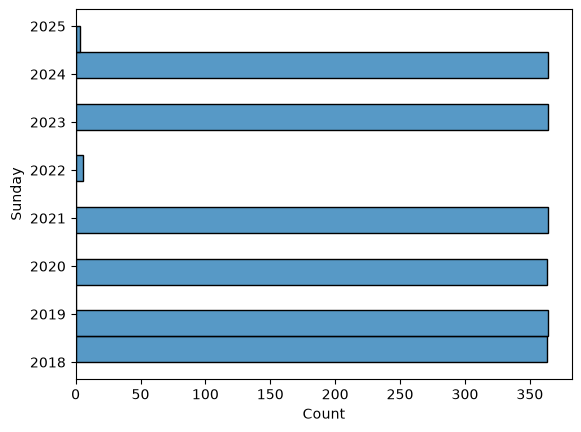

In [14]:
sns.histplot(data=data, y = pd.DatetimeIndex(data["Sunday"]).year)

<Axes: xlabel='Count', ylabel='Year'>

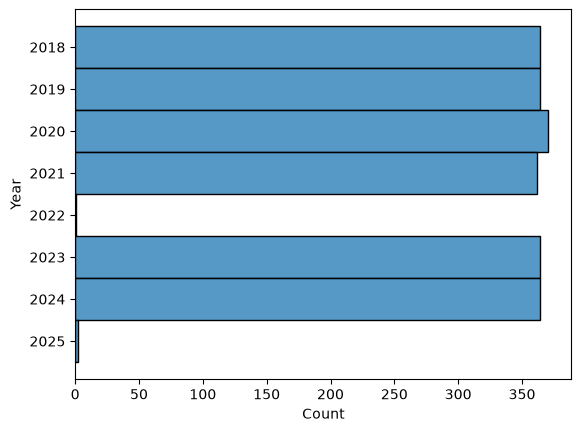

In [15]:
sns.histplot(data=data_weekly, y = data["Year"])

In [16]:
##There is no data for 2022, use an Arima model to imput values
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller


In [17]:
test = data_weekly[(data_weekly["Sunday"] >= "2021-01-01") & (data_weekly["Sunday"] < "2022-01-01")]
test = test.set_index("Sunday")
train = data_weekly[data_weekly["Sunday"] < "2021-01-01"]
train = train.set_index("Sunday")
display(train.head())
display(test.head())
y = train["AQI"]

,AQI,PM25,PM10,NO2,SO2,CO,O3
Sunday,,,,,,,
2018-01-07,394.500000,216.975000,426.060000,327.435000,449.730000,4.141667,374.775000
2018-01-14,331.428571,182.285714,357.942857,275.085714,377.828571,3.480000,314.857143
2018-01-21,341.285714,187.707143,368.588571,283.267143,389.065714,3.584286,324.221429
2018-01-28,286.000000,157.300000,308.880000,237.380000,326.040000,3.002857,271.700000
2018-02-04,275.142857,151.328571,297.154286,228.368571,313.662857,2.890000,261.385714


,AQI,PM25,PM10,NO2,SO2,CO,O3
Sunday,,,,,,,
2021-01-03,347.857143,191.321429,375.685714,288.721429,396.557143,3.652857,330.464286
2021-01-10,237.285714,130.507143,256.268571,196.947143,270.505714,2.492857,225.421429
2021-01-17,347.285714,191.007143,375.068571,288.247143,395.905714,3.645714,329.921429
2021-01-24,341.714286,187.942857,369.051429,283.622857,389.554286,3.587143,324.628571
2021-01-31,341.000000,187.550000,368.280000,283.030000,388.740000,3.580000,323.950000


In [129]:
import pmdarima as pmd

model=pmd.auto_arima(y,start_p=1,start_q=1,test='adf',m=52,seasonal=True,trace=True)

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,0,1)[52] intercept   : AIC=inf, Time=2.97 sec
 ARIMA(0,1,0)(0,0,0)[52] intercept   : AIC=1672.457, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[52] intercept   : AIC=1651.772, Time=0.65 sec
 ARIMA(0,1,1)(0,0,1)[52] intercept   : AIC=1652.843, Time=1.11 sec
 ARIMA(0,1,0)(0,0,0)[52]             : AIC=1670.458, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[52] intercept   : AIC=1661.844, Time=0.05 sec
 ARIMA(1,1,0)(2,0,0)[52] intercept   : AIC=inf, Time=8.43 sec
 ARIMA(1,1,0)(1,0,1)[52] intercept   : AIC=inf, Time=3.42 sec
 ARIMA(1,1,0)(0,0,1)[52] intercept   : AIC=1654.459, Time=1.03 sec
 ARIMA(1,1,0)(2,0,1)[52] intercept   : AIC=1650.817, Time=33.97 sec
 ARIMA(1,1,0)(2,0,2)[52] intercept   : AIC=inf, Time=18.07 sec
 ARIMA(1,1,0)(1,0,2)[52] intercept   : AIC=inf, Time=16.28 sec
 ARIMA(0,1,0)(2,0,1)[52] intercept   : AIC=1668.544, Time=12.27 sec
 ARIMA(2,1,0)(2,0,1)[52] intercept   : AIC=1647.797, Time=20.39 sec
 ARIMA(2,1,0)(1,0,1)[52] intercept   : 

In [18]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [19]:
model=SARIMAX(y,order=(2,1,0),seasonal_order=(2,0,1,52))
predicted=model.fit()

C:\Users\ranji\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Users\ranji\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Users\ranji\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [20]:
predicted_train = model.fit().predict();predicted

C:\Users\ranji\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [225]:
pd.DataFrame(predicted_train)

,predicted_mean
2018-01-07,0.000000
2018-01-14,394.051036
2018-01-21,354.266573
2018-01-28,348.963314
2018-02-04,308.144070
...,...
2020-11-29,281.780714
2020-12-06,327.292087
2020-12-13,330.309970
2020-12-20,349.892368


In [226]:
display(len(test))
display(len(train))

52

156

In [21]:
test_forecast = predicted.forecast(steps=len(test))

In [203]:
test_forecast

2021-01-03    367.925892
2021-01-10    300.470017
2021-01-17    316.954136
2021-01-24    267.865668
2021-01-31    278.369833
2021-02-07    272.704001
2021-02-14    271.317440
2021-02-21    244.451988
2021-02-28    222.136086
2021-03-07    203.340954
2021-03-14    208.746141
2021-03-21    209.239273
2021-03-28    203.542574
2021-04-04    206.124038
2021-04-11    205.912184
2021-04-18    203.687988
2021-04-25    228.494407
2021-05-02    216.392758
2021-05-09    241.758946
2021-05-16    218.012579
2021-05-23    216.683749
2021-05-30    221.135737
2021-06-06    197.930822
2021-06-13    243.017333
2021-06-20    195.879141
2021-06-27    174.711614
2021-07-04    182.324631
2021-07-11    183.118919
2021-07-18    158.694212
2021-07-25    142.230714
2021-08-01    153.498624
2021-08-08    143.838274
2021-08-15    131.954360
2021-08-22    143.840066
2021-08-29    141.339884
2021-09-05    150.360465
2021-09-12    155.244166
2021-09-19    163.158525
2021-09-26    152.145006
2021-10-03    176.913909


In [22]:
train["aqi_pred"] = pd.DataFrame(predicted_train)

In [23]:
test["aqi_pred"] = pd.DataFrame(test_forecast)

In [24]:
test.head()

,AQI,PM25,PM10,NO2,SO2,CO,O3,aqi_pred
Sunday,,,,,,,,
2021-01-03,347.857143,191.321429,375.685714,288.721429,396.557143,3.652857,330.464286,367.925896
2021-01-10,237.285714,130.507143,256.268571,196.947143,270.505714,2.492857,225.421429,300.470018
2021-01-17,347.285714,191.007143,375.068571,288.247143,395.905714,3.645714,329.921429,316.954137
2021-01-24,341.714286,187.942857,369.051429,283.622857,389.554286,3.587143,324.628571,267.865693
2021-01-31,341.000000,187.550000,368.280000,283.030000,388.740000,3.580000,323.950000,278.369846


In [25]:
date_2022 = pd.DataFrame({
    "Date": pd.date_range(start="2022-01-01", end="2022-12-31", freq="D")
    })

date_2022["Date"] = date_2022["Date"] + pd.offsets.Week(n=1, weekday=6)
date_2022 = date_2022.drop_duplicates().reset_index()
date_2022= date_2022.drop(columns="index")
future_forecast_aqi = pd.DataFrame(predicted.forecast(steps=(len(date_2022) * 2))).reset_index()
future_forecast_aqi = future_forecast_aqi.rename(columns={"index":"date", "predicted_mean":"predicted_aqi"})
future_forecast_aqi = future_forecast_aqi[(future_forecast_aqi["date"] >= "2022-01-01") & (future_forecast_aqi["date"] < "2023-01-01")]
future_forecast_aqi.head(10)

,date,predicted_aqi
52,2022-01-02,358.617374
53,2022-01-09,290.912285
54,2022-01-16,301.054390
55,2022-01-23,264.568769
56,2022-01-30,267.610337
57,2022-02-06,269.671546
58,2022-02-13,264.967725
59,2022-02-20,238.352315
60,2022-02-27,222.938701
61,2022-03-06,191.706764


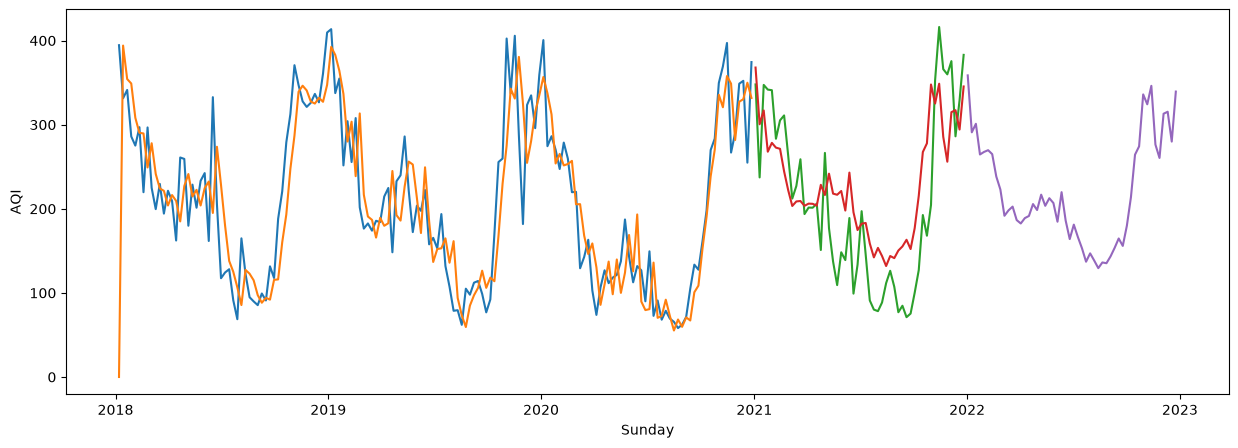

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))
sns.lineplot(x="Sunday", y= "AQI", data = train)
sns.lineplot(x="Sunday", y= "aqi_pred", data = train)
####################
sns.lineplot(x="Sunday", y= "AQI", data = test)
sns.lineplot(x="Sunday", y= "aqi_pred", data = test)
sns.lineplot(x="date", y= "predicted_aqi", data = future_forecast_aqi)
plt.show()

In [27]:
dftest = adfuller(train.AQI, autolag = 'AIC')
print("1. ADF : ",dftest[0])
print("2. P-Value : ", dftest[1])
print("3. Num Of Lags : ", dftest[2])
print("4. Num Of Observations Used For ADF Regression and Critical Values Calculation :", dftest[3])
print("5. Critical Values :")
for key, val in dftest[4].items():
    print("\t",key, ": ", val)

1. ADF :  -3.8804910909575314
2. P-Value :  0.0021832065044709572
3. Num Of Lags :  9
4. Num Of Observations Used For ADF Regression and Critical Values Calculation : 146
5. Critical Values :
	 1% :  -3.4759527332353084
	 5% :  -2.881548071241103
	 10% :  -2.577438765246763


In [28]:
result = adfuller(train["AQI"])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -3.880491
p-value: 0.002183


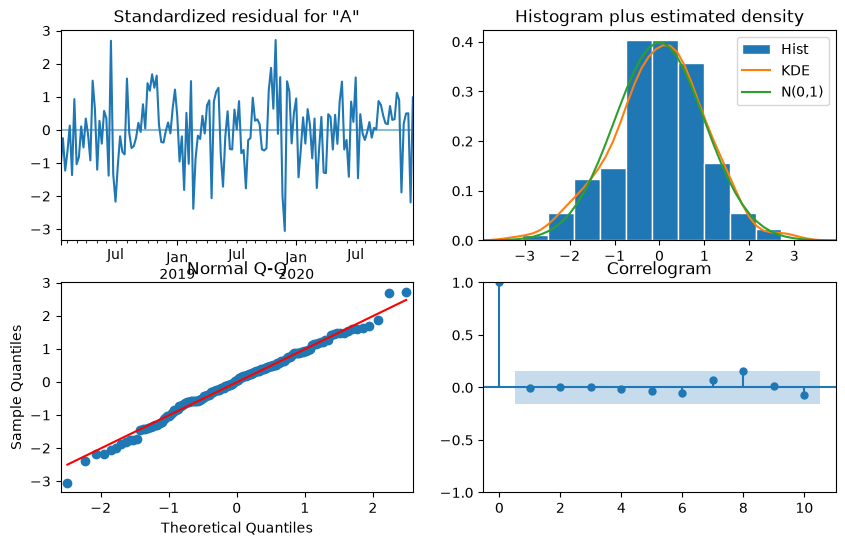

In [29]:
predicted.plot_diagnostics(figsize=(10,6))
plt.show()

In [30]:
forecast = test["aqi_pred"]
observed = test["AQI"]


from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
mae = mean_absolute_error(observed, forecast)
mse = mean_squared_error(observed, forecast)
rmse = root_mean_squared_error(observed, forecast)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

MAE: 54.59089124215869
MSE: 3955.7288601382334
RMSE: 62.894585300630084
